# 多分类神经网络实验

本实验基于 PyTorch，使用经典的**鸢尾花（Iris）数据集**，完成一个多分类神经网络的构建、训练与评估。

## 数据集说明

Iris 数据集包含 150 个样本，每个样本有 **4 个特征**（花萼长度、花萼宽度、花瓣长度、花瓣宽度），分属 **3 个类别**：
- 0：Setosa（山鸢尾）
- 1：Versicolor（变色鸢尾）  
- 2：Virginica（维吉尼亚鸢尾）

## 多分类与二分类的关键区别

| 对比项 | 二分类 | 多分类 |
|--------|--------|--------|
| 输出层激活函数 | Sigmoid | **Softmax**（或无，配合CrossEntropyLoss）|
| 损失函数 | BCELoss / MSELoss | **CrossEntropyLoss** |
| 输出节点数 | 1 | **类别数 C** |
| 预测方式 | > 0.5 → 正类 | argmax(输出) → 类别 |

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("依赖库导入成功！")

依赖库导入成功！


## 第一步：加载与探索数据

我们使用 `sklearn` 提供的鸢尾花数据集，并对特征进行**标准化**处理。

> 💡 **标准化**：将每个特征缩放到均值为 0、标准差为 1，可以加快训练收敛速度。

In [17]:
def load_and_explore_data():
    """加载鸢尾花数据集并打印基本信息"""
    iris = load_iris()
    X, y = iris.data.astype(np.float32), iris.target
    
    print("=== 数据集基本信息 ===")
    print(f"特征矩阵形状: {X.shape}  （样本数 × 特征数）")
    print(f"标签向量形状: {y.shape}")
    print(f"类别数量: {len(np.unique(y))}")
    print(f"类别名称: {iris.target_names.tolist()}")
    print(f"特征名称: {iris.feature_names}")
    print(f"\n各类别样本数: {dict(zip(iris.target_names, np.bincount(y)))}")
    
    return X, y, iris.target_names

X, y, class_names = load_and_explore_data()

=== 数据集基本信息 ===
特征矩阵形状: (150, 4)  （样本数 × 特征数）
标签向量形状: (150,)
类别数量: 3
类别名称: ['setosa', 'versicolor', 'virginica']
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

各类别样本数: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}


## 第二步：数据预处理与划分

将数据集划分为**训练集（80%）**和**测试集（20%）**，并进行标准化。

In [18]:
def preprocess_and_split(X, y, test_size=0.2, random_state=42):
    """数据划分与标准化"""
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # 标准化：用训练集的均值和方差对训练集和测试集都做归一化
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test  = scaler.transform(X_test).astype(np.float32)
    
    print(f"训练集大小: {X_train.shape[0]} 样本")
    print(f"测试集大小: {X_test.shape[0]} 样本")
    
    return X_train, X_test, y_train, y_test


def create_dataloader(X, y, batch_size=16, shuffle=True):
    """将 NumPy 数据转为 PyTorch DataLoader"""
    X_tensor = torch.tensor(X)
    # 注意：多分类的标签类型是 torch.long（整数），不是 float
    y_tensor = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return dataloader


X_train, X_test, y_train, y_test = preprocess_and_split(X, y)
train_loader = create_dataloader(X_train, y_train, batch_size=16, shuffle=True)
test_loader  = create_dataloader(X_test,  y_test,  batch_size=16, shuffle=False)

训练集大小: 120 样本
测试集大小: 30 样本


## 第三步：定义多分类神经网络

网络结构：
```
输入层 (4) → 全连接层 → ReLU → 全连接层 → ReLU → 输出层 (3)
```

> ⚠️ **注意**：输出层有 **3 个节点**（对应 3 个类别），不需要手动加 Softmax，因为 `CrossEntropyLoss` 内部已经包含了 Softmax 操作。

### ✏️ TODO：请补全网络定义

In [19]:
class MultiClassNN(nn.Module):
    def __init__(self, input_size=4, hidden_size=16, num_classes=3):
        super(MultiClassNN, self).__init__()
        
        # ====== 【作业 1】定义网络各层 ======
        # 参考结构：输入层(4) → 全连接 → ReLU → 全连接 → ReLU → 输出层(3)
        # 提示：
        #   nn.Linear(in_features, out_features)  定义全连接层
        #   nn.ReLU()                             定义激活函数
        # 注意：最后一层输出节点数 = num_classes，不加激活函数
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)
       
        # YOUR CODE HERE
        #raise NotImplementedError
    
    def forward(self, x):
        # ====== 【作业 2】定义前向传播 ======
        # 提示：依次让数据通过你在 __init__ 中定义的层
        # 顺序：fc1 → relu → fc2 → relu → fc3
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
        # YOUR CODE HERE
        #raise NotImplementedError


# 实例化并打印模型结构
model = MultiClassNN(input_size=4, hidden_size=16, num_classes=3)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"模型总参数数量: {total_params}")


MultiClassNN(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=3, bias=True)
)
模型总参数数量: 403


## 第四步：训练函数

训练流程（每个 batch）：
1. **前向传播**：输入 → 网络 → 预测输出
2. **计算损失**：预测输出 vs 真实标签
3. **反向传播**：计算梯度
4. **参数更新**：优化器更新权重

### ✏️ TODO：请补全训练循环

In [20]:
def train_model(model, train_loader, criterion, optimizer, num_epochs):
    """训练模型，返回每个 epoch 的平均损失列表"""
    loss_history = []
    
    for epoch in range(num_epochs):
        model.train()          # 切换到训练模式
        total_loss = 0.0
        num_batches = 0
        
        for inputs, labels in train_loader:
            
            # ====== 【作业 3】补全训练的 5 个步骤 ======
            
            # 步骤 1：前向传播，得到预测值 outputs
            # YOUR CODE HERE
            outputs=model(inputs)
            
            # 步骤 2：用 criterion 计算损失 loss
            loss=criterion(outputs,labels)
            # YOUR CODE HERE
            
            # 步骤 3：梯度清零（防止上一个 batch 的梯度累积）
            # YOUR CODE HERE
            optimizer.zero_grad()
            
            # 步骤 4：反向传播（计算梯度）
            loss.backward()
            # YOUR CODE HERE
            
            # 步骤 5：优化器更新参数
            optimizer.step()
            # YOUR CODE HERE
            
            total_loss += loss.item()
            num_batches += 1
        
        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}], Loss: {avg_loss:.4f}")
    
    return loss_history

print("训练函数定义完成。")


训练函数定义完成。


## 第五步：评估函数

在测试集上评估模型，计算**准确率**，并输出每个类别的预测情况。

In [21]:
def test_model(model, X_test, y_test, class_names):
    """在测试集上评估多分类模型"""
    model.eval()  # 切换到评估模式
    
    with torch.no_grad():  # 评估时不需要计算梯度
        X_tensor = torch.tensor(X_test)
        outputs  = model(X_tensor)    # 输出形状：(N, 3)
        
        # ====== 【作业 4】从 outputs 得到预测类别 ======
        # 提示：torch.max(tensor, dim=1) 返回 (最大值, 最大值所在索引)
        #       多分类的预测类别 = 输出中最大值对应的索引
        _, predicted = torch.max(outputs, dim=1)
        predicted = predicted.numpy()
        # YOUR CODE HERE：把预测结果存入 predicted（numpy 数组）
        #raise NotImplementedError
    
    # ====== 【作业 5】计算整体准确率 ======
    # 提示：准确率 = 预测正确的样本数 / 总样本数
    accuracy = (predicted == y_test).sum() / len(y_test)
    # YOUR CODE HERE：将准确率存入 accuracy
    #raise NotImplementedError
    
    print(f"测试集准确率: {accuracy:.4f} ({int(accuracy * len(y_test))}/{len(y_test)})")
    
    # 各类别准确率（已给出，无需修改）
    print("各类别准确率:")
    for i, name in enumerate(class_names):
        mask = y_test == i
        class_acc = np.mean(predicted[mask] == y_test[mask])
        print(f"  {name:20s}: {class_acc:.4f}")
    
    return predicted

print("评估函数定义完成。")


评估函数定义完成。


## 第六步：可视化函数

绘制训练损失曲线，观察模型是否收敛。

In [22]:
def visualize_loss(loss_history):
    """绘制训练损失曲线"""
    plt.figure(figsize=(6, 4))
    plt.plot(loss_history, color='steelblue', linewidth=1.5)
    plt.title('Training Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (CrossEntropy)')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


def visualize_predictions(X_test, y_test, predicted, class_names):
    """用前两个特征可视化预测结果（正确/错误用不同标记）"""
    colors = ['#4C72B0', '#DD8452', '#55A868']
    markers_correct = ['o', 's', '^']
    
    plt.figure(figsize=(7, 5))
    for i, name in enumerate(class_names):
        mask = y_test == i
        correct   = mask & (predicted == y_test)
        incorrect = mask & (predicted != y_test)
        
        plt.scatter(X_test[correct, 0],   X_test[correct, 1],
                    c=colors[i], marker=markers_correct[i],
                    label=f'{name} (correct)', s=60, edgecolors='white', linewidths=0.5)
        plt.scatter(X_test[incorrect, 0], X_test[incorrect, 1],
                    c=colors[i], marker='x',
                    label=f'{name} (wrong)', s=100, linewidths=2)
    
    plt.title('Test Set Predictions (Feature 1 vs Feature 2)')
    plt.xlabel('Feature 1 (Sepal Length, standardized)')
    plt.ylabel('Feature 2 (Sepal Width, standardized)')
    plt.legend(loc='best', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("可视化函数定义完成。")

可视化函数定义完成。


## 第七步：主函数——组装并运行

### ✏️ TODO：请填写超参数（学习率和训练轮数）

=== 数据集基本信息 ===
特征矩阵形状: (150, 4)  （样本数 × 特征数）
标签向量形状: (150,)
类别数量: 3
类别名称: ['setosa', 'versicolor', 'virginica']
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

各类别样本数: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}
训练集大小: 120 样本
测试集大小: 30 样本
开始训练...
Epoch [ 10/100], Loss: 0.9271
Epoch [ 20/100], Loss: 0.6897
Epoch [ 30/100], Loss: 0.5423
Epoch [ 40/100], Loss: 0.4738
Epoch [ 50/100], Loss: 0.4116
Epoch [ 60/100], Loss: 0.3584
Epoch [ 70/100], Loss: 0.3287
Epoch [ 80/100], Loss: 0.2980
Epoch [ 90/100], Loss: 0.2831
Epoch [100/100], Loss: 0.2739
=== 测试结果 ===
测试集准确率: 0.8333 (25/30)
各类别准确率:
  setosa              : 1.0000
  versicolor          : 0.6000
  virginica           : 0.9000


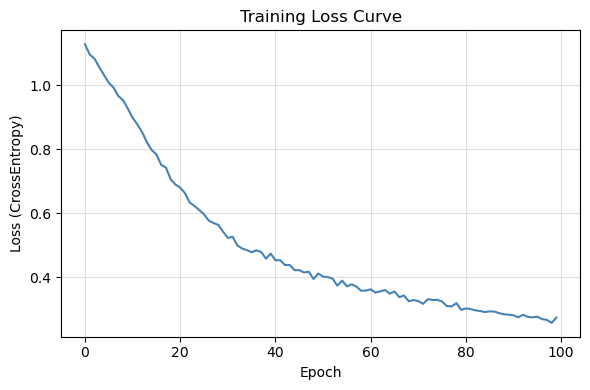

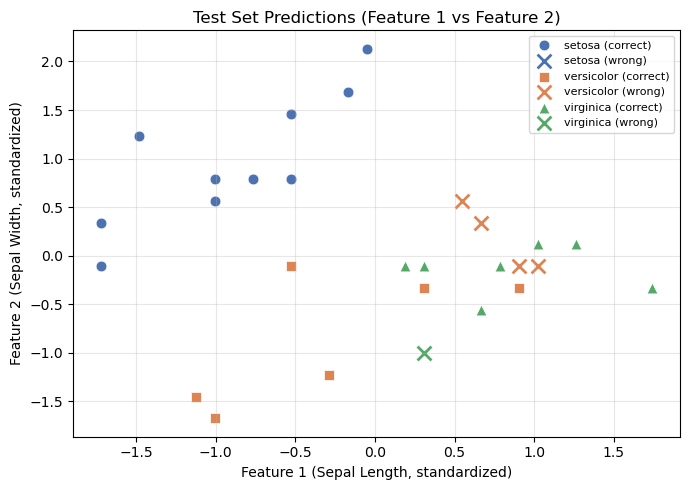

In [23]:
def main():
    # ====== 【作业 6】填写超参数 ======
    learning_rate = 0.01   # 建议范围：0.001 ~ 0.1
    num_epochs    =100  # 建议范围：50 ~ 300
    batch_size    = 16    # 已给出，无需修改
    hidden_size   =48  # 建议范围：8 ~ 64
    # =================================
    
    # 数据准备（已给出）
    X, y, class_names = load_and_explore_data()
    X_train, X_test, y_train, y_test = preprocess_and_split(X, y)
    train_loader = create_dataloader(X_train, y_train, batch_size=batch_size, shuffle=True)
    
    # 模型实例化（已给出）
    model = MultiClassNN(input_size=4, hidden_size=hidden_size, num_classes=3)
    
    # ====== 【作业 7】选择损失函数和优化器 ======
    # 提示：多分类应使用 nn.CrossEntropyLoss()
    criterion = nn.CrossEntropyLoss()   # YOUR CODE HERE
    
    # 提示：可选 optim.SGD 或 optim.Adam，需传入 model.parameters() 和 lr
    optimizer = optim.SGD(model.parameters(),lr=learning_rate)  # YOUR CODE HERE
    # ============================================
    
    # 训练、测试、可视化（已给出）
    print("开始训练...")
    loss_history = train_model(model, train_loader, criterion, optimizer, num_epochs)
    
    print("=== 测试结果 ===")
    predicted = test_model(model, X_test, y_test, class_names)
    
    visualize_loss(loss_history)
    visualize_predictions(X_test, y_test, predicted, class_names)


main()


## 🔬 思考与拓展

完成基础实验后，可以尝试以下方向：

1. **调整超参数**：修改 `learning_rate`、`num_epochs`、`hidden_size`，观察对准确率的影响

2. **换用优化器**：将 `Adam` 改为 `SGD`，对比收敛速度差异

3. **加深网络**：在 `MultiClassNN` 中再增加一个全连接层，看准确率是否提升

4. **加入 Dropout**：在全连接层之间添加 `nn.Dropout(p=0.3)`，观察是否能防止过拟合

5. **混淆矩阵**：使用 `sklearn.metrics.confusion_matrix` 分析模型在哪个类别上容易出错

```python
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, predicted))
print(classification_report(y_test, predicted, target_names=class_names))
```